## 1. Imports and Setup

In [9]:
# === Imports ===

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Enable SHAP visualizations inside the notebook
shap.initjs()

## 2. Load Data and Trained Model


In [10]:
# === Load cleaned dataset ===

X = pd.read_csv("../data/clean_credit_data.csv")

# === Load trained best model ===

best_model = joblib.load("models/best_model.pkl")

## 3. Sample a Subset for Faster SHAP Computation

In [11]:
# === Sample 1000 records for SHAP analysis to save time ===

X_sample = X.sample(n=1000, random_state=42).reset_index(drop=True)

## 4. Create Explainer and Compute SHAP Values

In [12]:
# === Create SHAP explainer for the model ===

explainer = shap.TreeExplainer(best_model)

# === Compute SHAP values ===

shap_values = explainer.shap_values(X_sample)

## 5. SHAP Summary Plot (Feature Importance)

<Figure size 640x480 with 0 Axes>

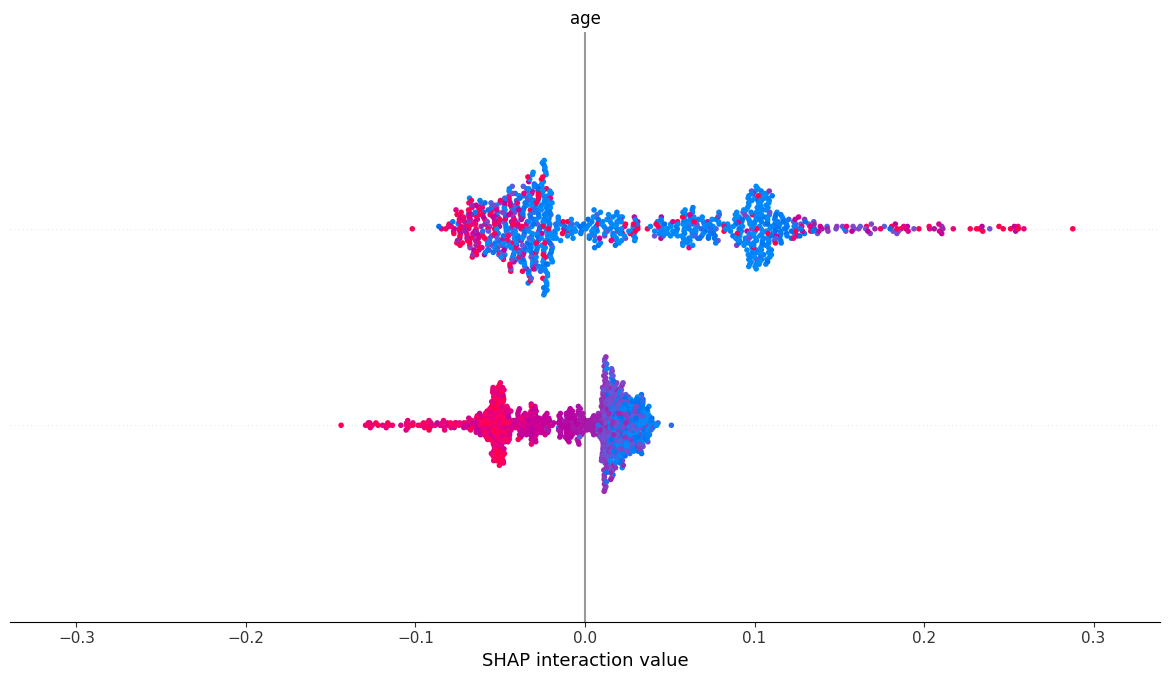

In [13]:
# === If multiclass (e.g., shap_values is a list), use class 1 ===

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]  # for class 1 (default = 1)
else:
    shap_values_to_plot = shap_values

# === Plot global feature importance as a bar chart ===

shap.summary_plot(shap_values_to_plot, X_sample, plot_type="bar")

## 6. SHAP Dependence Plot for Top Feature

In [14]:
# === Get most impactful feature and plot dependence ===

if shap_values_to_plot.ndim == 2:
    # Identify top feature by average absolute SHAP value
    top_feature = X_sample.columns[np.abs(shap_values_to_plot).mean(0).argmax()]
    print("Top feature by SHAP impact:", top_feature)

    # Plot how this feature interacts with model output
    shap.dependence_plot(top_feature, shap_values_to_plot, X_sample)
else:
    print("⚠️ Unexpected SHAP shape:", shap_values_to_plot.shape)

⚠️ Unexpected SHAP shape: (1000, 11, 2)
